# Exercises

There are three exercises in this notebook:

1. Use the cross-validation method to test the linear regression with different $\alpha$ values, at least three.
2. Implement a SGD method that will train the Lasso regression for 10 epochs.
3. Extend the Fisher's classifier to work with two features. Use the class as the $y$.

## 1. Cross-validation linear regression

You need to change the variable ``alpha`` to be a list of alphas. Next do a loop and finally compare the results.

In [26]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

In [ ]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])

I = np.identity(2)
alpha_list = [0.01, 0.1, 1.0, 10.0, 100.0]

results = []
for alpha in alpha_list:
    w = np.linalg.inv(x.T*x + alpha * I)*x.T*y
    w=w.ravel()
    results.append(w)

df = pd.DataFrame(
    [[alpha, np.asarray(w)[0,0], np.asarray(w)[0,1]] for alpha, w in zip(alpha_list, results)],
    columns=["alpha", "bias", "slope"]
)
df



,alpha,bias,slope
0,0.01,-167.855340,1.544160
1,0.10,-101.723971,1.169788
2,1.00,-20.590447,0.710486
3,10.00,-2.291063,0.606881
4,100.00,-0.228730,0.595091


## 2. Implement based on the Ridge regression example, the Lasso regression.

Please implement the SGD method and compare the results with the sklearn Lasso regression results. 

In [24]:
def sgd(x, y, alpha, epochs, lr=1e-5):
    w = np.zeros(x.shape[1])
    
    for epoch in range(epochs):
        for i in range(x.shape[0]):
            xi = np.asarray(x[i]).flatten()
            yi = float(y[i])
            y_pred = xi @ w
            grad = -xi * (yi - y_pred) + alpha * np.sign(w)
            w = w - lr * grad
    return w

In [25]:
x = np.array([188, 181, 197, 168, 167, 187, 178, 194, 140, 176, 168, 192, 173, 142, 176]).reshape(-1, 1).reshape(15,1)
y = np.array([141, 106, 149, 59, 79, 136, 65, 136, 52, 87, 115, 140, 82, 69, 121]).reshape(-1, 1).reshape(15,1)

x = np.asmatrix(np.c_[np.ones((15,1)),x])
x_arr = np.asarray(x)
y_arr = np.asarray(y).flatten()

I = np.identity(2)
alpha = 0.1 


w = sgd(x_arr, y_arr, alpha, epochs=1000)
w=w.ravel()

lasso = Lasso(alpha=0.1, fit_intercept=False)
lasso.fit(x_arr, y_arr)

print(f"SGD:    w0={w[0]:.4f}, w1={w[1]:.4f}")
print(f"Sklearn: w0={lasso.coef_[0]:.4f}, w1={lasso.coef_[1]:.4f}")


SGD:    w0=-0.2209, w1=0.6046
Sklearn: w0=-168.1947, w1=1.5461


## 3. Extend the Fisher's classifier

Write numpy code that performs Fisher classification using all the features of Iris data. Choose species nr 1 and 2 as two classes. Plot original data and their projection. Using obtained model classify the flower with the folowing features: [6.45, 2.85, 4.25, 1.25].

In [31]:
from sklearn.datasets import load_iris
from sklearn import preprocessing
import matplotlib.pyplot as plt

In [40]:
iris_data , iris_labels = load_iris(return_X_y = True)
iris_data = np.array(preprocessing.normalize(iris_data))

x1 = iris_data [iris_labels == 1] 
x2 = iris_data [iris_labels == 2] 

mean_x1 = np.mean( x1 , axis =0)
mean_x2 = np.mean( x2 , axis =0)
Sw = (x1 - mean_x1).T @ (x1 - mean_x1) + (x2 - mean_x2).T @ (x2 - mean_x2)

w = np.dot( np.linalg.inv( Sw ) , ( mean_x2 - mean_x1 ) )

proj1 = x1 @ w
proj2 = x2 @ w

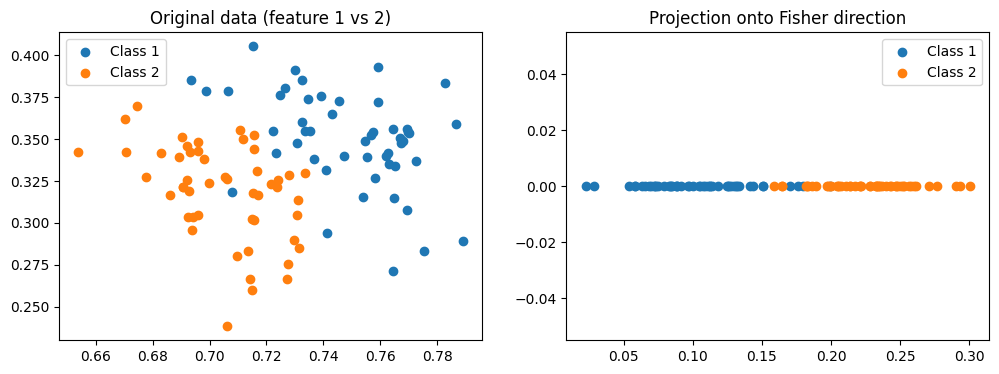

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.scatter(x1[:, 0], x1[:, 1], label='Class 1')
ax1.scatter(x2[:, 0], x2[:, 1], label='Class 2')
ax1.set_title('Original data (feature 1 vs 2)')
ax1.legend()

ax2.scatter(proj1, np.zeros(len(proj1)), label='Class 1')
ax2.scatter(proj2, np.zeros(len(proj2)), label='Class 2')
ax2.set_title('Projection onto Fisher direction')
ax2.legend()
plt.show()

In [42]:
threshold = (np.mean(proj1) + np.mean(proj2)) / 2
new_point = np.array([6.45, 2.85, 4.25, 1.25])
new_point_norm = new_point / np.linalg.norm(new_point)
projection = new_point_norm @ w

predicted_class = 2 if projection > threshold else 1
print(f"Projection: {projection:.4f}, Threshold: {threshold:.4f}")
print(f"Predicted class: {predicted_class}")

Projection: 0.0664, Threshold: 0.1652
Predicted class: 1
